In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATASET_PATH = PROJECT_ROOT / "data" / "bangla_news.csv"

print("Dataset exists:", DATASET_PATH.exists())

Dataset exists: True


In [3]:
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully")
print("Rows and Columns:", df.shape)

Dataset loaded successfully
Rows and Columns: (11904, 6)


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Column names:
['title', 'published_date', 'reporter', 'category', 'url', 'content']

First 5 rows:


,title,published_date,reporter,category,url,content
0,"সিন নদীতে ব্যাপক দূষণ, স্থগিত করা হলো ট্রায়াথ...","30th July, 2024 5:59 pm",আরআইএম,sports,https://jamuna.tv/news/552127,ছবি: সংগৃহীত সিন নদীতে অলিম্পিকের উদ্বোধনী অনু...
1,এসিসির নতুন সভাপতি হচ্ছেন মহসিন নাকভি!,"30th July, 2024 5:25 pm",NaN,sports,https://jamuna.tv/news/552123,২০২৫ সালের জানুয়ারিতে এশিয়ান ক্রিকেট কাউন্স...
2,২০৩০ ও ২০৩৪ বিশ্বকাপের হোস্ট জানা যাবে দুইদিন পর!,"30th July, 2024 1:22 pm",আরআইএম,sports,https://jamuna.tv/news/552066,ফিফা বিশ্বকাপ ২০৩০ ও ৩৪ সালের স্বাগতিক হবার ল...
3,প্যারিস অলিম্পিক: কোয়ার্টার ফাইনালে ওঠার লক্ষ্...,"30th July, 2024 11:54 am",এনকে,sports,https://jamuna.tv/news/552046,প্যারিস অলিম্পিকে কোয়ার্টার ফাইনাল রেসে টিকে ...
4,আজ টিভিতে যা দেখবেন (৩০ জুলাই ২০২৪),"30th July, 2024 7:01 am",এনকে,sports,https://jamuna.tv/news/552016,আজ ভারত–শ্রীলঙ্কার তৃতীয় টি–টোয়েন্টি অলিম্পিকে...


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
title               0
published_date      0
reporter          990
category            0
url                 0
content             0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate article contents:", df["content"].duplicated().sum())

print("Duplicate URLs:", df["url"].duplicated().sum())

Duplicate rows: 0
Duplicate article contents: 59
Duplicate URLs: 55


In [7]:
df["content_length"] = df["content"].str.len()

print(df["content_length"].describe())

count    11904.000000
mean       506.579889
std        179.443955
min          2.000000
25%        392.000000
50%        483.000000
75%        594.000000
max       3455.000000
Name: content_length, dtype: float64


In [8]:
shortest = df.nsmallest(10, "content_length")

display(
    shortest[["title", "content_length", "content"]]
)

,title,content_length,content
4975,যুক্তরাষ্ট্রে একসাথে ৪৩টি গাড়ির সংঘর্ষ!,2,
11427,গুলশানে ‘কাচ্চি ভাই’কে লাখ টাকা জরিমানা,2,
6041,লাপাতা লেডিস: মিষ্টি প্রেমের মোড়কে নারীর বঞ্চন...,11,আল মাহফুজ
6103,"আবার দেখা হবে, খালিদ?",11,আল মাহফুজ
6113,তানজারিন: যে কমলা যুদ্ধ-বিরোধিতার কথা বলে,11,আল মাহফুজ
5820,ছবি: ইসরায়েলি হামলায় ঘরবাড়ি ছাড়ছেন ফিলিস্তি...,21,ছবি: আল জাজিরা। /এআই
1392,আজ টিভিতে দেখা যাবে যেসব খেলা (৬ এপ্রিল),27,আইপিএল রাজস্থান-বেঙ্গালুরু
2679,তাইজুল! দ্য আনসাং হিরো অব বাংলাদেশ,36,তাইজুল ইসলাম। ছবি: ফেসবুক পেজ। /এআই
603,আজ টিভিতে দেখা যাবে যেসব খেলা (১২ জুন),38,টি–টোয়েন্টি বিশ্বকাপ শ্রীলঙ্কা–নেপাল
1275,আজ টিভিতে দেখা যাবে যেসব খেলা (২১ এপ্রিল),40,৩য় টি–টোয়েন্টি পাকিস্তান–নিউজিল্যান্ড


In [9]:
print("Number of categories:", df["category"].nunique())

print("\nArticles per category:")
print(df["category"].value_counts())

Number of categories: 4

Articles per category:
category
sports           2976
international    2976
entertainment    2976
national         2976
Name: count, dtype: int64


In [10]:
duplicate_urls = df[df["url"].duplicated(keep=False)]

display(
    duplicate_urls[
        ["title", "url", "content_length"]
    ].sort_values("url").head(20)
)

,title,url,content_length
2801,বিশ্বকাপ ফাইনালে তারকার হাট,https://jamuna.tv/news/496707,485
6406,বিশ্বকাপ ফাইনালে তারকার হাট,https://jamuna.tv/news/496707,485
2555,শাহরুখ-প্রীতির পর ক্রিকেটে দল কিনলেন অক্ষয়,https://jamuna.tv/news/502700,428
6340,শাহরুখ-প্রীতির পর ক্রিকেটে দল কিনলেন অক্ষয়,https://jamuna.tv/news/502700,428
11874,সকল গীতিকারই ‘কবি’ নয়: লতিফুল ইসলাম শিবলী,https://jamuna.tv/news/517105,733
6209,সকল গীতিকারই ‘কবি’ নয়: লতিফুল ইসলাম শিবলী,https://jamuna.tv/news/517105,733
4772,সড়ক দুর্ঘটনায় প্রাণ গেল ম্যারাথনে বিশ্ব রেকর...,https://jamuna.tv/news/517145,586
1966,সড়ক দুর্ঘটনায় প্রাণ গেল ম্যারাথনে বিশ্ব রেকর...,https://jamuna.tv/news/517145,586
4688,নিউইয়র্কে ইলিয়াস হোসেন গ্রেফতার,https://jamuna.tv/news/518532,328
11768,নিউইয়র্কে ইলিয়াস হোসেন গ্রেফতার,https://jamuna.tv/news/518532,328


In [11]:
short_articles = df[df["content_length"] < 100]

print("Articles shorter than 100 characters:", len(short_articles))

display(
    short_articles[
        ["title", "content_length", "content"]
    ].head(20)
)

Articles shorter than 100 characters: 18


,title,content_length,content
603,আজ টিভিতে দেখা যাবে যেসব খেলা (১২ জুন),38,টি–টোয়েন্টি বিশ্বকাপ শ্রীলঙ্কা–নেপাল
1275,আজ টিভিতে দেখা যাবে যেসব খেলা (২১ এপ্রিল),40,৩য় টি–টোয়েন্টি পাকিস্তান–নিউজিল্যান্ড
1295,আজ টিভিতে দেখা যাবে যেসব খেলা (১৭ এপ্রিল),57,উয়েফা চ্যাম্পিয়নস লিগ ম্যানচেস্টার সিটি–রিয...
1392,আজ টিভিতে দেখা যাবে যেসব খেলা (৬ এপ্রিল),27,আইপিএল রাজস্থান-বেঙ্গালুরু
2679,তাইজুল! দ্য আনসাং হিরো অব বাংলাদেশ,36,তাইজুল ইসলাম। ছবি: ফেসবুক পেজ। /এআই
3093,সপ্তাহের আলোচিত কিছু ছবি ও গল্প,96,চলতি সপ্তাহে বিশ্বজুড়ে তোলা আকর্ষণীয় কিছু ফ...
4975,যুক্তরাষ্ট্রে একসাথে ৪৩টি গাড়ির সংঘর্ষ!,2,
5790,"ফিলিপাইনের ক্যাথলিক সমাবেশে বিস্ফোরণ, নিহত ৪",91,ফিলিপাইনের মিন্দানাও স্টেট ইউনিভার্সিটির জিমনে...
5820,ছবি: ইসরায়েলি হামলায় ঘরবাড়ি ছাড়ছেন ফিলিস্তি...,21,ছবি: আল জাজিরা। /এআই
5864,ছবিতে এক নজরে বন্যা ও তুষারঝড়ে বিপর্যস্ত ইউক্র...,87,রাশিয়ার ব্ল্যাক সি বন্দরে বড় বড় ঢেউ শহরের সম...


In [12]:
duplicate_content = df[
    df["content"].duplicated(keep=False)
].sort_values("content")

display(
    duplicate_content[
        ["title", "url", "content"]
    ].head(10)
)

,title,url,content
4975,যুক্তরাষ্ট্রে একসাথে ৪৩টি গাড়ির সংঘর্ষ!,https://jamuna.tv/news/513880,
11427,গুলশানে ‘কাচ্চি ভাই’কে লাখ টাকা জরিমানা,https://jamuna.tv/news/522832,
11737,বাংলাদেশের মানুষ ‘মায়ের মতো ভালো’: অনিন্দ্য চট...,https://jamuna.tv/news/518825,অনিন্দ্য চট্টোপাধ্যায়ের পরিচয়ের অন্ত নেই। জনপ...
6188,বাংলাদেশের মানুষ ‘মায়ের মতো ভালো’: অনিন্দ্য চট...,https://jamuna.tv/news/518825,অনিন্দ্য চট্টোপাধ্যায়ের পরিচয়ের অন্ত নেই। জনপ...
6167,প্রকাশিত হলো রুদ্র আরিফের ‘সিনেঅলা ৪’,https://jamuna.tv/news/520233,অমর একুশে বইমেলায় প্রকাশিত হয়েছে চলচ্চিত্র ...
11643,প্রকাশিত হলো রুদ্র আরিফের ‘সিনেঅলা ৪’,https://jamuna.tv/news/520233,অমর একুশে বইমেলায় প্রকাশিত হয়েছে চলচ্চিত্র ...
6113,তানজারিন: যে কমলা যুদ্ধ-বিরোধিতার কথা বলে,https://jamuna.tv/news/525153,আল মাহফুজ
6103,"আবার দেখা হবে, খালিদ?",https://jamuna.tv/news/526166,আল মাহফুজ
6041,লাপাতা লেডিস: মিষ্টি প্রেমের মোড়কে নারীর বঞ্চন...,https://jamuna.tv/news/534443,আল মাহফুজ
4264,"মালয়েশিয়ায় মর্গে পড়ে আছে বাংলাদেশির মরদেহ,...",https://jamuna.tv/news/527027,"আহমাদুল কবির, মালয়েশিয়া: মালয়েশিয়ার পেরাক..."


In [13]:
# Create a trimmed version for inspection only
content_trimmed = df["content"].fillna("").astype(str).str.strip()

print("Empty or whitespace-only content:", (content_trimmed == "").sum())

# Inspect articles containing very little text
short_mask = content_trimmed.str.len() < 20

display(
    df.loc[short_mask, ["title", "content"]]
)

Empty or whitespace-only content: 2


,title,content
4975,যুক্তরাষ্ট্রে একসাথে ৪৩টি গাড়ির সংঘর্ষ!,
6041,লাপাতা লেডিস: মিষ্টি প্রেমের মোড়কে নারীর বঞ্চন...,আল মাহফুজ
6103,"আবার দেখা হবে, খালিদ?",আল মাহফুজ
6113,তানজারিন: যে কমলা যুদ্ধ-বিরোধিতার কথা বলে,আল মাহফুজ
11427,গুলশানে ‘কাচ্চি ভাই’কে লাখ টাকা জরিমানা,


Data Cleaning

In [14]:
df_clean = df.copy()

# Remove rows with missing or whitespace-only article content
df_clean["content"] = df_clean["content"].fillna("").astype(str).str.strip()
df_clean = df_clean[df_clean["content"] != ""].copy()

print("Original records:", len(df))
print("Records after removing empty content:", len(df_clean))

Original records: 11904
Records after removing empty content: 11902


In [15]:
# Keep the first record for each URL
df_clean = df_clean.drop_duplicates(subset="url", keep="first").copy()

print("Records after removing duplicate URLs:", len(df_clean))
print("Remaining duplicate URLs:", df_clean["url"].duplicated().sum())

Records after removing duplicate URLs: 11847
Remaining duplicate URLs: 0


In [16]:
# Inspect records where content is suspiciously short
short_content = df_clean[
    df_clean["content"].str.strip().str.len() < 20
]

display(
    short_content[
        ["title", "reporter", "content", "content_length"]
    ]
)

,title,reporter,content,content_length
6041,লাপাতা লেডিস: মিষ্টি প্রেমের মোড়কে নারীর বঞ্চন...,২০১০ সালে ‘ধোবি ঘাট’ নামে দুর্দান্ত এক সিনেমার...,আল মাহফুজ,11
6103,"আবার দেখা হবে, খালিদ?",“আমায় যদি পড়ে মনেকবিতায় কবিতায়মগ্ন থেকোআসে...,আল মাহফুজ,11
6113,তানজারিন: যে কমলা যুদ্ধ-বিরোধিতার কথা বলে,NaN,আল মাহফুজ,11


In [17]:
# Remove records whose entire content is only a reporter's name
reporter_names = {"আল মাহফুজ"}

metadata_only = (
    df_clean["content"].str.strip().isin(reporter_names)
)

print("Metadata-only records found:", metadata_only.sum())

df_clean = df_clean.loc[~metadata_only].copy()

print("Records after removing metadata-only content:", len(df_clean))

Metadata-only records found: 3
Records after removing metadata-only content: 11844


In [18]:
print("Articles per category after cleaning:")
print(df_clean["category"].value_counts())

print("\nCategory percentages:")
print(
    (df_clean["category"].value_counts(normalize=True) * 100)
    .round(2)
)

Articles per category after cleaning:
category
sports           2976
international    2972
entertainment    2961
national         2935
Name: count, dtype: int64

Category percentages:
category
sports           25.13
international    25.09
entertainment    25.00
national         24.78
Name: proportion, dtype: float64


In [19]:
print("Original dataset size:", df.shape)
print("Cleaned dataset size:", df_clean.shape)

print("\nEmpty content remaining:", (df_clean["content"] == "").sum())
print("Duplicate URLs remaining:", df_clean["url"].duplicated().sum())

display(df_clean[["title", "category", "content"]].head())

Original dataset size: (11904, 7)
Cleaned dataset size: (11844, 7)

Empty content remaining: 0
Duplicate URLs remaining: 0


,title,category,content
0,"সিন নদীতে ব্যাপক দূষণ, স্থগিত করা হলো ট্রায়াথ...",sports,ছবি: সংগৃহীত সিন নদীতে অলিম্পিকের উদ্বোধনী অনু...
1,এসিসির নতুন সভাপতি হচ্ছেন মহসিন নাকভি!,sports,২০২৫ সালের জানুয়ারিতে এশিয়ান ক্রিকেট কাউন্সি...
2,২০৩০ ও ২০৩৪ বিশ্বকাপের হোস্ট জানা যাবে দুইদিন পর!,sports,ফিফা বিশ্বকাপ ২০৩০ ও ৩৪ সালের স্বাগতিক হবার লড়...
3,প্যারিস অলিম্পিক: কোয়ার্টার ফাইনালে ওঠার লক্ষ্...,sports,প্যারিস অলিম্পিকে কোয়ার্টার ফাইনাল রেসে টিকে থ...
4,আজ টিভিতে যা দেখবেন (৩০ জুলাই ২০২৪),sports,আজ ভারত–শ্রীলঙ্কার তৃতীয় টি–টোয়েন্টি অলিম্পিকে...


In [20]:
df_clean["content_length"] = df_clean["content"].str.len()

print(df_clean["content_length"].describe())

count    11844.000000
mean       506.550574
std        179.443305
min         20.000000
25%        392.000000
50%        483.000000
75%        594.000000
max       3455.000000
Name: content_length, dtype: float64


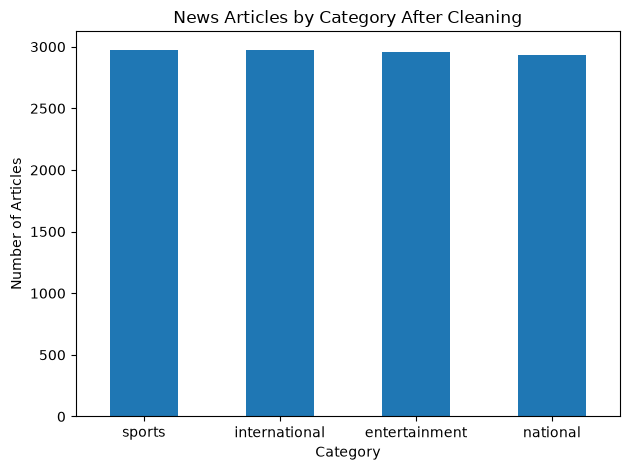

In [21]:
df_clean["category"].value_counts().plot(kind="bar")

plt.title("News Articles by Category After Cleaning")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()